# Mixtral: практикум

Теория: глава учебника [Mixtral](../docs/textbook/mixtral.md) и глава [Mixture-of-Experts](../docs/textbook/mixture-of-experts.md). Реализация: [`llm/src/llm/models/mixtral/mixtral.py`](../llm/src/llm/models/mixtral/mixtral.py).

По сравнению с Mistral в Mixtral новое только одно: вместо плотного SwiGLU в каждом блоке стоит **Mixture-of-Experts**, восемь SwiGLU-экспертов и роутер, который для каждого токена выбирает двух. Скользящего окна у Mixtral 8x7B нет. Поэтому в этом ноутбуке:

1. **Пишем сами** слой MoE по формулам из главы, сначала наивно по токенам, потом циклом по экспертам, и **load-balancing loss**.
2. **Сверяем** с `MoE` и `load_balancing_loss` из библиотеки на одних и тех же весах.
3. **Собираем модель** из своего MoE и блоков библиотеки, сверяем с `llm.models.mixtral.Mixtral`.
4. **Обучаем** учебный конфиг дважды, без load-balancing loss и с ним, и генерируем текст.
5. **Смотрим внутрь**: как токены распределяются по экспертам, сколько параметров активно.
6. **Упражнения.**

Запуск из корня репозитория: `uv sync --extra dev`, затем `uv run jupyter lab notebooks/mixtral.ipynb`. Все ячейки выполняются на CPU за несколько минут.

In [1]:
import contextlib
import io
import json
import math
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn

# корень репозитория: нужен для experiments/shared и конфигов экспериментов
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

torch.manual_seed(0)
print(f"torch {torch.__version__}, репозиторий: {ROOT}")

torch 2.8.0, репозиторий: /Users/penkovsky_sa/Projects/OpenIdeaLab/ML/llm-arch-research/.claude/worktrees/analyze-notebooks-64589d


## 1. Пишем сами: Mixture-of-Experts

Формулы из главы ([MoE](../docs/textbook/mixtral.md#прямой-проход-в-формулах)). Для каждого токена $\mathbf{u} \in \mathbb{R}^{d}$ роутер даёт логиты по экспертам, из них выбираются $k$ наибольших, softmax берётся **только по выбранным**, и выход это взвешенная сумма выходов выбранных экспертов:

$$
\mathbf{g} = \mathbf{u} W_r, \qquad \mathcal{S} = \mathrm{TopK}(\mathbf{g}, k), \qquad
w_i = \frac{e^{g_i}}{\sum_{j \in \mathcal{S}} e^{g_j}}, \qquad
\mathrm{MoE}(\mathbf{u}) = \sum_{i \in \mathcal{S}} w_i\, \mathrm{SwiGLU}_i(\mathbf{u})
$$

Эксперт это обычный `SwiGLU` из библиотеки. Начнём с прямого перевода формулы: цикл по токенам. Так считать медленно, зато это эталон для проверки.

In [2]:
from llm.core.swi_glu import SwiGLU


def moe_per_token(router, experts, top_k, u):
    # u: [N, d]. Формула как есть: для каждого токена свои k экспертов.
    outputs = []
    for row in u:
        g = router(row)                                   # [E] логиты роутера
        chosen = torch.topk(g, top_k).indices             # S: индексы k лучших
        w = F.softmax(g[chosen], dim=-1)                  # веса только по выбранным
        outputs.append(sum(w_i * experts[i](row[None, None])[0, 0] for w_i, i in zip(w, chosen)))
    return torch.stack(outputs)

В модели так не делают: эксперту выгодно получить все свои токены одной матрицей. Поэтому цикл идёт по экспертам ([Алгоритм](../docs/textbook/mixtral.md#алгоритм)): для эксперта $e$ находим токены, у которых он в top-k, прогоняем их разом и прибавляем взвешенный результат на свои места. Имена полей как в библиотеке, чтобы переносить веса через `state_dict`; `router_logits` последнего прохода сохраняем, он понадобится для load-balancing loss.

In [3]:
class MyMoE(nn.Module):
    def __init__(self, emb_size, num_experts, top_k_experts, dropout=0.1):
        super().__init__()
        self._num_experts, self._top_k = num_experts, top_k_experts
        self._router = nn.Linear(emb_size, num_experts)
        self._experts = nn.ModuleList([SwiGLU(emb_size=emb_size, dropout=0.0) for _ in range(num_experts)])
        self._dropout = nn.Dropout(dropout)  # один dropout на выходе, у экспертов своего нет
        self.router_logits = None

    def forward(self, x):
        B, T, D = x.shape
        u = x.reshape(-1, D)                                                  # N = B·T токенов
        logits = self._router(u)                                              # [N, E]
        self.router_logits = logits
        topk_logits, topk_idx = torch.topk(logits, self._top_k, dim=-1)       # [N, k]
        weights = F.softmax(topk_logits, dim=-1)                              # softmax только по выбранным
        out = torch.zeros_like(u)
        for e, expert in enumerate(self._experts):
            tokens, slot = torch.where(topk_idx == e)   # dispatch: какие токены выбрали e и на каком месте
            if tokens.numel() == 0:
                continue                                 # эксперта никто не выбрал, не вызываем
            expert_out = expert(u[tokens].unsqueeze(0)).squeeze(0)            # [n_e, D] одним вызовом
            out.index_add_(0, tokens, weights[tokens, slot, None] * expert_out)  # combine
        return self._dropout(out.reshape(B, T, D))

**Load-balancing loss** ([формула](../docs/textbook/mixtral.md#load-balancing-loss)). Без него роутер может отправлять все токены к паре «любимых» экспертов. К loss модели прибавляется

$$
\mathcal{L}_{\text{aux}} = E \sum_{s=1}^{k} \sum_{i=0}^{E-1} f_{s,i}\, P_i
$$

где $f_{s,i}$ доля токенов, у которых эксперт $i$ стоит на месте $s$ в top-k, а $P_i$ средняя по токенам вероятность эксперта $i$ в softmax по **всем** экспертам. При равномерной загрузке сумма равна $k$, перекос её увеличивает. Статистика собирается по всем слоям сразу.

In [4]:
def my_load_balancing_loss(router_logits_per_layer, num_experts, top_k):
    logits = torch.cat(list(router_logits_per_layer), dim=0)                 # [N_total, E] по всем слоям
    probs = F.softmax(logits, dim=-1)                                        # softmax по всем экспертам
    chosen = torch.topk(probs, top_k, dim=-1).indices                        # [N, k]
    f = F.one_hot(chosen, num_experts).float().mean(dim=0)                   # [k, E]: f_{s,i}
    P = probs.mean(dim=0)                                                    # [E]: P_i
    return num_experts * (f * P).sum()


E, k = 8, 2
uniform = torch.zeros(1000, E)                      # роутер одинаково относится ко всем экспертам
collapsed = torch.zeros(1000, E); collapsed[:, :2] = 5.0   # всегда выбирает экспертов 0 и 1
print(f"равномерная загрузка: {my_load_balancing_loss([uniform], E, k):.3f} (ожидаем k = {k})")
print(f"коллапс на двух экспертов: {my_load_balancing_loss([collapsed], E, k):.3f}")

равномерная загрузка: 2.000 (ожидаем k = 2)
коллапс на двух экспертов: 7.841


## 2. Сверяем с библиотекой

Три реализации должны дать одно и то же: наивный цикл по токенам, наш `MyMoE` и библиотечный `MoE`. Dropout выключаем.

In [5]:
from llm.core.moe import MoE, load_balancing_loss

mine = MyMoE(emb_size=32, num_experts=8, top_k_experts=2, dropout=0.0).eval()
lib = MoE(emb_size=32, num_experts=8, top_k_experts=2, dropout=0.0).eval()
lib.load_state_dict(mine.state_dict())

x = torch.randn(2, 12, 32)
out_mine, out_lib = mine(x), lib(x)
out_naive = moe_per_token(mine._router, mine._experts, 2, x.reshape(-1, 32)).reshape(2, 12, 32)
assert torch.allclose(out_mine, out_naive, atol=1e-5), "цикл по экспертам не совпал с циклом по токенам"
assert torch.allclose(out_mine, out_lib, atol=1e-6), "не совпало с библиотекой"
assert torch.allclose(my_load_balancing_loss([mine.router_logits], 8, 2), load_balancing_loss([lib.router_logits], 8, 2))
print("MoE и load-balancing loss совпадают с библиотекой")

# dispatch на пальцах: кто кого выбрал
topk_idx = torch.topk(mine.router_logits, 2, dim=-1).indices
print("первые 6 токенов -> эксперты:", topk_idx[:6].tolist())
print("токенов у каждого эксперта:  ", torch.bincount(topk_idx.flatten(), minlength=8).tolist(), "(сумма = N·k =", topk_idx.numel(), ")")

MoE и load-balancing loss совпадают с библиотекой
первые 6 токенов -> эксперты: [[6, 1], [1, 7], [7, 3], [5, 7], [5, 7], [7, 1]]
токенов у каждого эксперта:   [4, 6, 4, 5, 4, 6, 8, 11] (сумма = N·k = 48 )


## 3. Собираем модель из блоков

Блок такой же, как у Mistral, только вместо `SwiGLU` стоит `MoE` ([формулы](../docs/textbook/mixtral.md#прямой-проход-в-формулах)):

$$
U^{(l)} = H^{(l-1)} + \mathrm{GQA}\big(\mathrm{RMSNorm}_1(H^{(l-1)})\big), \qquad
H^{(l)} = U^{(l)} + \mathrm{MoE}\big(\mathrm{RMSNorm}_2(U^{(l)})\big)
$$

Внимание берём из библиотеки, оно разобрано в [mistral.ipynb](mistral.ipynb). Модель наследует `generate`, `save` и `load` от `BaseModel`, а метод `auxiliary_loss` возвращает $\alpha \cdot \mathcal{L}_{\text{aux}}$ по логитам роутеров последнего прохода: именно его `Trainer` прибавляет к loss после каждого `forward`.

In [6]:
from llm.core.base_model import BaseModel
from llm.core.group_query_attention import GroupedQueryAttention
from llm.core.rms_norm import RMSNorm
from llm.core.rope import RoPE
from llm.core.token_embeddings import TokenEmbeddings


class MyMixtralDecoder(nn.Module):
    def __init__(self, num_q_heads, num_kv_heads, emb_size, head_size, max_seq_len, num_experts, top_k_experts, rope, dropout):
        super().__init__()
        self._heads = GroupedQueryAttention(num_q_heads=num_q_heads, num_kv_heads=num_kv_heads, emb_size=emb_size,
                                            head_size=head_size, max_seq_len=max_seq_len, rope=rope, dropout=dropout)
        self._ff = MyMoE(emb_size, num_experts, top_k_experts, dropout)
        self._norm1 = RMSNorm(emb_size)
        self._norm2 = RMSNorm(emb_size)

    def forward(self, x, use_cache=False, cache=None):
        attn, new_cache = self._heads(self._norm1(x), use_cache=use_cache, cache=cache)
        u = x + attn
        return u + self._ff(self._norm2(u)), new_cache


class MyMixtral(BaseModel):
    def __init__(self, config):
        super().__init__(config)
        d = config["embed_dim"]
        head_size = config.get("head_size") or d // config["num_q_heads"]
        self._max_seq_len = config["max_position_embeddings"]
        self._aux_coef = config.get("router_aux_loss_coef", 0.0)
        self._token_embeddings = TokenEmbeddings(config["vocab_size"], d)
        self._position_embeddings = RoPE(head_size=head_size, max_seq_len=self._max_seq_len)
        self._dropout = nn.Dropout(config["dropout"])
        self._decoders = nn.ModuleList([
            MyMixtralDecoder(config["num_q_heads"], config["num_kv_heads"], d, head_size, self._max_seq_len,
                             config["num_experts"], config["top_k_experts"], self._position_embeddings, config["dropout"])
            for _ in range(config["num_layers"])
        ])
        self._norm = RMSNorm(d)
        self._linear = nn.Linear(d, config["vocab_size"])

    def forward(self, x, use_cache=False, cache=None, attention_mask=None):
        assert attention_mask is None, "паддинг здесь не поддерживаем, см. core/padding.py в библиотеке"
        start_pos = cache[0][2] if cache is not None else 0
        assert start_pos + x.size(1) <= self._max_seq_len
        h = self._dropout(self._token_embeddings(x))
        new_cache = []
        for i, decoder in enumerate(self._decoders):
            h, layer_cache = decoder(h, use_cache=use_cache, cache=None if cache is None else cache[i])
            new_cache.append(layer_cache)
        return self._linear(self._norm(h)), (new_cache if use_cache else None)

    def auxiliary_loss(self):
        if self._aux_coef == 0:
            return None
        logits = [decoder._ff.router_logits for decoder in self._decoders]
        return self._aux_coef * my_load_balancing_loss(logits, self.config["num_experts"], self.config["top_k_experts"])

Сверяем с `llm.models.mixtral.Mixtral` на учебном конфиге из `mixtral_train.json`, включив load-balancing loss с коэффициентом 0.01 в обеих моделях. Словарь появится после обучения токенизатора, пока подставим любой размер.

In [7]:
from llm.models.mixtral import Mixtral

experiment = json.loads((ROOT / "experiments/llm_only/configs/mixtral_train.json").read_text())
config = dict(experiment["model_config"], vocab_size=300, router_aux_loss_coef=0.01)
print(json.dumps(config, indent=2))

lib_model = Mixtral(config).eval()
my_model = MyMixtral(config).eval()
my_model.load_state_dict(lib_model.state_dict())

ids = torch.randint(0, config["vocab_size"], (2, 40))
assert torch.allclose(my_model(ids)[0], lib_model(ids)[0], atol=1e-5), "логиты различаются"
assert torch.allclose(my_model.auxiliary_loss(), lib_model.auxiliary_loss()), "auxiliary_loss различается"
gen_my = my_model.generate(ids[:, :5], max_new_tokens=30, do_sample=False)
gen_lib = lib_model.generate(ids[:, :5], max_new_tokens=30, do_sample=False)
assert torch.equal(gen_my, gen_lib), "генерация различается"
print(f"Логиты, auxiliary_loss = {my_model.auxiliary_loss():.4f} и жадная генерация совпадают с библиотечной моделью.")

total = sum(p.numel() for p in lib_model.parameters())
experts = sum(p.numel() for n, p in lib_model.named_parameters() if "_experts" in n)
one_expert = sum(p.numel() for p in lib_model._decoders[0]._ff._experts[0].parameters())
active = total - experts + config["num_layers"] * config["top_k_experts"] * one_expert
print(f"Параметров всего: {total:,}, из них экспертов: {experts:,} ({experts / total:.1%}); активных на токен: {active:,}")

{
  "vocab_size": 300,
  "embed_dim": 256,
  "num_q_heads": 4,
  "num_kv_heads": 2,
  "head_size": 64,
  "num_layers": 4,
  "max_position_embeddings": 512,
  "num_experts": 8,
  "top_k_experts": 2,
  "dropout": 0.1,
  "router_aux_loss_coef": 0.01
}


Логиты, auxiliary_loss = 0.0205 и жадная генерация совпадают с библиотечной моделью.
Параметров всего: 26,193,484, из них экспертов: 25,239,552 (96.4%); активных на токен: 7,263,820


Тот же подсчёт для Mixtral 8x7B, без выделения памяти, на `meta`-устройстве ([Подсчёт параметров](../docs/textbook/mixtral.md#подсчёт-параметров)): 46.7 млрд всего, 12.9 млрд активных.

In [8]:
with torch.device("meta"):
    big = Mixtral({"vocab_size": 32000, "embed_dim": 4096, "num_q_heads": 32, "num_kv_heads": 8, "head_size": 128,
                   "num_layers": 32, "max_position_embeddings": 32768, "num_experts": 8, "top_k_experts": 2,
                   "dropout": 0.0, "intermediate_size": 14336, "bias": False, "rope_theta": 1e6, "rms_norm_eps": 1e-5})
total = sum(p.numel() for p in big.parameters())
one_expert = sum(p.numel() for p in big._decoders[0]._ff._experts[0].parameters())
experts = sum(p.numel() for n, p in big.named_parameters() if "_experts" in n)
print(f"всего {total:,}; активных {total - experts + 32 * 2 * one_expert:,}; один эксперт {one_expert:,}")

всего 46,702,792,704; активных 12,879,925,248; один эксперт 176,160,768


## 4. Обучение

Дальше работаем с библиотечной `Mixtral`. Корпус и конфиг те же, что у скрипта `experiments/llm_only/run_llm_experiment.py`, только эпох больше и в конец каждого текста добавлен `<eos>`, чтобы генерация умела останавливаться. Обучаем две модели: с `router_aux_loss_coef = 0` (по умолчанию, как в скрипте) и с `0.01`, чтобы в разделе 5 сравнить загрузку экспертов.

In [9]:
from experiments.shared.configs import TRAIN_TEXTS
from llm.datasets.text_with_special_tokens_dataset import TextWithSpecialTokensDataset
from llm.tokenizers import BPETokenizer
from llm.training.trainer import Trainer

experiment = json.loads((ROOT / "experiments/llm_only/configs/mixtral_train.json").read_text())
train_texts, val_texts = TRAIN_TEXTS[:12], TRAIN_TEXTS[12:]

tokenizer = BPETokenizer()
tokenizer.train(train_texts, vocab_size=experiment["bpe_vocab_size"], special_tokens=experiment["bpe_special_tokens"])
print(tokenizer)
print(tokenizer.tokenize(train_texts[0]))

block_size = 64  # самый длинный текст корпуса короче
# add_eos: модель учится ставить <eos> в конце предложения, и generate остановится на нём
train_dataset = TextWithSpecialTokensDataset(train_texts, tokenizer, block_size=block_size, add_eos=True)
val_dataset = TextWithSpecialTokensDataset(val_texts, tokenizer, block_size=block_size, add_eos=True)
print(f"примеров: train {len(train_dataset)}, val {len(val_dataset)}; "
      f"токенов в самом длинном: {max(len(e) for e in train_dataset.examples)}")

BPETokenizer(vocab_size=426)
['Мир', ' программирования', ' прекрасен', ' и', ' удивителен', '.']
примеров: train 12, val 3; токенов в самом длинном: 14


In [10]:
def train_model(config, num_epochs=40, seed=0):
    # Обучает Mixtral на учебном корпусе. Прогресс-бар и loss по эпохам уходят в буфер,
    # история loss остаётся в trainer.loss_history.
    training = experiment["training"]
    torch.manual_seed(seed)
    model = Mixtral(config)
    trainer = Trainer(model, train_dataset, val_dataset, lr=training["learning_rate"],
                      batch_size=training["batch_size"], num_epochs=num_epochs, warmup_ratio=training["warmup_ratio"])
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        trainer.train()
        trainer.val_loss = trainer.evaluate()
    model.eval()
    return trainer


def plot_history(*trainers, labels=None):
    fig, ax = plt.subplots(figsize=(6, 3))
    for i, t in enumerate(trainers):
        ax.plot(range(1, len(t.loss_history) + 1), t.loss_history, label=None if labels is None else labels[i])
    ax.set_xlabel("эпоха"); ax.set_ylabel("train loss"); ax.grid(alpha=0.3)
    if labels:
        ax.legend()
    plt.show()

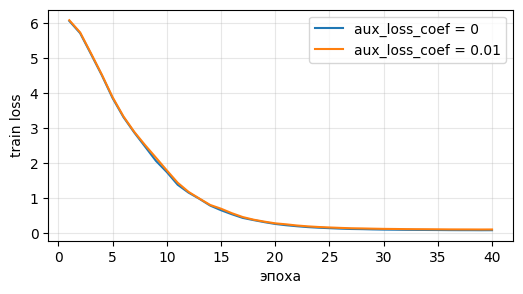

без load-balancing   train loss 6.055 -> 0.073, validation loss 8.315
с load-balancing     train loss 6.076 -> 0.094, validation loss 8.171


In [11]:
config = dict(experiment["model_config"], vocab_size=tokenizer.vocab_size)
trainer_plain = train_model(config, num_epochs=40)
trainer_balanced = train_model(dict(config, router_aux_loss_coef=0.01), num_epochs=40)
model = trainer_plain.model

plot_history(trainer_plain, trainer_balanced, labels=["aux_loss_coef = 0", "aux_loss_coef = 0.01"])
for name, t in (("без load-balancing", trainer_plain), ("с load-balancing", trainer_balanced)):
    print(f"{name:<20} train loss {t.loss_history[0]:.3f} -> {t.loss_history[-1]:.3f}, validation loss {t.val_loss:.3f}")

Train loss с load-balancing loss включает вспомогательное слагаемое, около $\alpha k = 0.02$ при ровной загрузке, поэтому кривые не совпадают по уровню. Валидационный loss растёт: корпус из 12 предложений модель запоминает, а не выучивает язык.

In [12]:
def generate_text(model, prompt, **kwargs):
    ids = torch.tensor([tokenizer.encode(prompt)])
    out = model.generate(ids, max_new_tokens=25, eos_token_id=tokenizer.eos_token_id, **kwargs)
    return tokenizer.decode(out[0])


torch.manual_seed(1)
for prompt in experiment["test_prompts"] + ["Нейронные сети"]:
    print(f"{prompt!r}")
    print("  жадно:   ", generate_text(model, prompt, do_sample=False))
    print("  T = 0.8: ", generate_text(model, prompt, do_sample=True, temperature=0.8))

'Машинное обучение'
  жадно:    Машинное обучение находит применение в различных областях науки и техники.
  T = 0.8:  Машинное обучение находит применение в различных областях науки и техники.
'Мир программирования'
  жадно:    Мир программирования прекрасен и удивителен.
  T = 0.8:  Мир программирования прекрасен и удивителен.
'Нейронные сети'
  жадно:    Нейронные сети имитируют работу человеческого мозга.
  T = 0.8:  Нейронные сети имитируют работу человеческого мозга.


`save` и `load` наследуются от `BaseModel`: в файл уходит конфиг и `state_dict`, таблицы RoPE и маски не сохраняются и пересчитываются при загрузке.

In [13]:
with tempfile.TemporaryDirectory() as tmp:
    path = Path(tmp) / "model.pt"
    model.save(path)
    restored = Mixtral.load(path)
    print(f"файл: {path.stat().st_size / 1024:.0f} КиБ")
ids = torch.tensor([tokenizer.encode(train_texts[1])])
assert torch.allclose(model(ids)[0], restored(ids)[0], atol=1e-6)
print("Логиты загруженной модели совпадают.")

файл: 102644 КиБ
Логиты загруженной модели совпадают.


## 5. Смотрим внутрь

### Кто к кому ходит

Каждый `MoE` хранит `router_logits` последнего прохода. Прогоняем весь обучающий корпус и считаем, сколько токенов попало к каждому эксперту в каждом слое. Сумма по строке равна $N \cdot k$: каждый токен идёт ровно к двум экспертам.

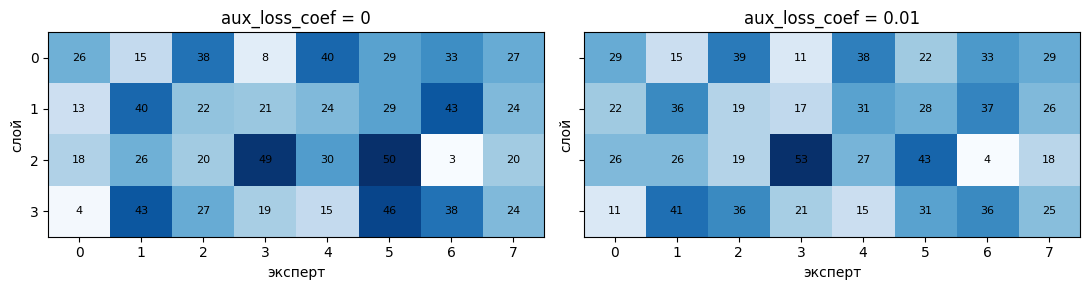

aux_loss_coef = 0      самый загруженный эксперт получает [40, 43, 50, 46] токенов по слоям из 216
aux_loss_coef = 0.01   самый загруженный эксперт получает [39, 37, 53, 41] токенов по слоям из 216


In [14]:
def expert_load(m, texts):
    # [num_layers, num_experts]: сколько токенов корпуса выбрали эксперта (в top-k)
    E, k = m.config["num_experts"], m.config["top_k_experts"]
    counts = torch.zeros(m.config["num_layers"], E, dtype=torch.long)
    with torch.no_grad():
        for text in texts:
            m(torch.tensor([tokenizer.encode(text)]))
            for layer, decoder in enumerate(m._decoders):
                chosen = torch.topk(decoder._ff.router_logits, k, dim=-1).indices
                counts[layer] += torch.bincount(chosen.flatten(), minlength=E)
    return counts


loads = {"aux_loss_coef = 0": expert_load(trainer_plain.model, train_texts),
         "aux_loss_coef = 0.01": expert_load(trainer_balanced.model, train_texts)}
fig, axes = plt.subplots(1, 2, figsize=(11, 3), sharey=True)
for ax, (name, counts) in zip(axes, loads.items()):
    im = ax.imshow(counts, cmap="Blues", aspect="auto")
    for i in range(counts.shape[0]):
        for j in range(counts.shape[1]):
            ax.text(j, i, int(counts[i, j]), ha="center", va="center", fontsize=8)
    ax.set_title(name); ax.set_xlabel("эксперт"); ax.set_ylabel("слой")
    ax.set_xticks(range(counts.shape[1])); ax.set_yticks(range(counts.shape[0]))
plt.tight_layout(); plt.show()
for name, counts in loads.items():
    print(f"{name:<22} самый загруженный эксперт получает {counts.max(dim=1).values.tolist()} токенов по слоям из {int(counts[0].sum())}")

Ожидание: без вспомогательного loss у роутера появляются «любимые» эксперты, с ним загрузка ровнее. На двух сотнях токенов и 240 шагах обучения разница в пределах шума: перекос есть в обеих моделях и в основном унаследован от случайной инициализации роутера. Эффект проявляется на длинном обучении и больших коэффициентах, см. упражнение 2. Теперь вопрос из учебника про специализацию: ходят ли знаки препинания к одним и тем же экспертам?

In [15]:
def experts_for_tokens(m, texts, predicate):
    # Для токенов, подходящих под predicate, список выбранных экспертов по слоям
    result = {layer: [] for layer in range(m.config["num_layers"])}
    with torch.no_grad():
        for text in texts:
            ids = tokenizer.encode(text)
            m(torch.tensor([ids]))
            for layer, decoder in enumerate(m._decoders):
                chosen = torch.topk(decoder._ff.router_logits, m.config["top_k_experts"], dim=-1).indices
                for pos, tid in enumerate(ids):
                    if predicate(tokenizer.inverse_vocab[tid]):
                        result[layer].append(tuple(sorted(chosen[pos].tolist())))
    return result


punct = experts_for_tokens(trainer_balanced.model, train_texts, lambda tok: tok.strip() in {".", ","})
for layer, pairs in punct.items():
    unique = sorted(set(pairs))
    print(f"слой {layer}: {len(pairs)} знаков препинания, пары экспертов {unique}")

слой 0: 12 знаков препинания, пары экспертов [(2, 7)]
слой 1: 12 знаков препинания, пары экспертов [(1, 3), (1, 4)]
слой 2: 12 знаков препинания, пары экспертов [(2, 4), (2, 5)]
слой 3: 12 знаков препинания, пары экспертов [(2, 6)]


Если все знаки препинания слоя ушли к одной паре экспертов, это и есть «синтаксическая» специализация, о которой пишут авторы Mixtral. На учебном корпусе она может как появиться, так и нет: модель видела всего 12 предложений.

### Сколько работы делает один токен

Сравним время прямого прохода MoE с плотным FFN такого же скрытого размера и с FFN размером «все восемь экспертов вместе». Активных параметров у MoE столько же, сколько у двух экспертов, но в памяти лежат все восемь.

In [16]:
import time

d, N = 256, 4096
u = torch.randn(1, N, d)
moe = MoE(emb_size=d, num_experts=8, top_k_experts=2, dropout=0.0).eval()
dense_2 = SwiGLU(emb_size=d, hidden_dim=2 * 4 * d, dropout=0.0).eval()   # как два эксперта
dense_8 = SwiGLU(emb_size=d, hidden_dim=8 * 4 * d, dropout=0.0).eval()   # как все восемь


def timeit(fn, repeats=5):
    with torch.no_grad():
        fn()
        start = time.perf_counter()
        for _ in range(repeats):
            fn()
    return (time.perf_counter() - start) / repeats * 1000


for name, module in (("MoE 8 экспертов, k = 2", moe), ("плотный FFN = 2 эксперта", dense_2), ("плотный FFN = 8 экспертов", dense_8)):
    params = sum(p.numel() for p in module.parameters())
    print(f"{name:<28} параметров {params:>10,}   {timeit(lambda: module(u)):6.1f} мс на {N} токенов")

MoE 8 экспертов, k = 2       параметров  6,311,944     20.8 мс на 4096 токенов


плотный FFN = 2 эксперта     параметров  1,577,216     13.7 мс на 4096 токенов


плотный FFN = 8 экспертов    параметров  6,308,096     54.7 мс на 4096 токенов


## 6. Упражнения

Расчётные вопросы с ответами в конце главы учебника: [Вопросы и упражнения](../docs/textbook/mixtral.md#вопросы-и-упражнения). Ниже задачи для этого ноутбука.

1. **Switch Transformer.** Обучите модель с `top_k_experts = 1`. Как меняются loss, время эпохи и загрузка экспертов? Сколько слагаемых получает каждый токен?
2. **Коэффициент load-balancing.** Повторите обучение с `router_aux_loss_coef` 0.001, 0.1 и 1. Найдите значение, при котором загрузка выравнивается, но loss языковой модели ещё не страдает.
3. **Коллапс роутера.** Напечатайте `router_logits` первого слоя до обучения и после. Насколько роутер уверен в своём выборе, то есть как далеко веса $w_i$ от $1/k$?
4. **Цикл по токенам против цикла по экспертам.** Замерьте `moe_per_token` и `MyMoE` на 4096 токенах. Во сколько раз отличается время и почему?
5. **Окно в Mixtral.** Добавьте в конфиг `window_size: 8` и обучите. У Mixtral 8x7B окна нет, но для учебного корпуса это ни на что не влияет, так ли это? Проверьте рецептивное поле кодом из [mistral.ipynb](mistral.ipynb).